## 🎮 Video Game Sales Analysis

### 📌 Objective
Analyze global video game sales data to uncover patterns across **genre, platform, publisher, and region**, and generate **data-driven recommendations** for game developers.

### 🎯 Key Questions
- Which publishers dominate the market?
- Which genres generate the highest sales?
- How do preferences differ across regions?
- Which platforms perform best globally and regionally?

#### 🧾 1. IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set(style='whitegrid')

#### 📥 2. DATA LOADING

In [3]:
df = pd.read_csv('vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.shape

(16598, 11)

📌 Insight

Dataset contains ~16K rows of video game sales data across multiple regions.

#### 🧠 3. DATA UNDERSTANDING

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


The dataset includes:
- Categorical variables: Name, Platform, Genre, Publisher  
- Numerical variables: Sales across regions and globally  
- Year of release

#### 🧹 4. DATA CLEANING

In [5]:
# Check missing values
df.isnull().sum()

# Drop missing values in critical columns
df = df.dropna(subset=['Year', 'Publisher'])

In [6]:
# Convert Year
df['Year'] = df['Year'].astype(int)

# Check duplicate
df.duplicated().sum()

np.int64(0)

### ✅ Cleaning Summary
- Removed missing values in Year & Publisher  
- Ensured correct data types  
- No duplicate data found  

#### 📊 5. EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
plt.rcParams.update({
    "figure.facecolor": "#0a192f",
    "axes.facecolor": "#0f223a",
    "axes.edgecolor": "#1e293b",
    "axes.labelcolor": "#cbd5f5",
    "xtick.color": "#94a3b8",
    "ytick.color": "#94a3b8",
    "text.color": "#e2e8f0",
    "axes.titleweight": "bold",
    "font.size": 11,

    # 🔥 TAMBAHAN INI
    "axes.prop_cycle": plt.cycler(color=[
        "#3b82f6", "#60a5fa", "#2563eb", "#1d4ed8",
        "#1e40af", "#93c5fd", "#38bdf8", "#0ea5e9"
    ])
})

##### 🎮 5.1 Top Publishers

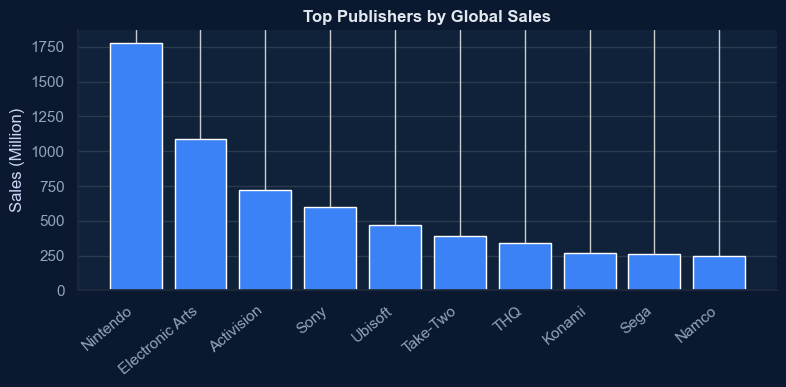

In [8]:
publishers = [
    "Nintendo","Electronic Arts","Activision",
    "Sony","Ubisoft","Take-Two",
    "THQ","Konami","Sega","Namco"
]

sales = [1780,1090,720,600,470,390,340,270,260,250]

plt.figure(figsize=(8,4))

ax = plt.bar(publishers, sales)

plt.xticks(rotation=40, ha='right')
plt.title('Top Publishers by Global Sales')
plt.ylabel('Sales (Million)')

plt.grid(axis='y', alpha=0.15)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

📌 Insight
- **Nintendo dominates the market significantly**, far ahead of competitors  
- Indicates strong IP ownership and global market penetration  

##### 🎯 5.2 Genre Analysis

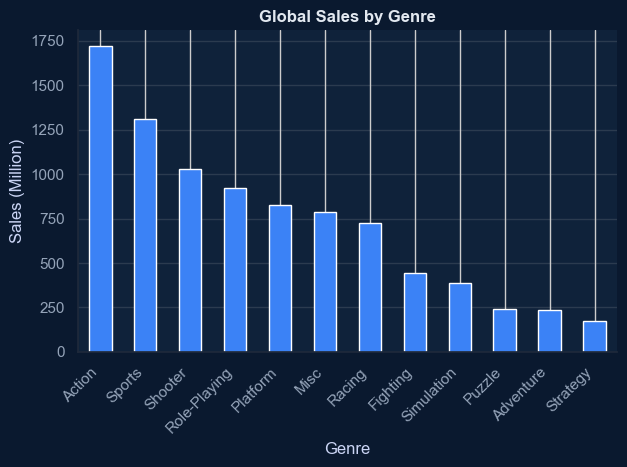

In [10]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure()

ax = genre_sales.plot(kind='bar')

plt.title('Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Sales (Million)')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', alpha=0.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

📌 Insight
- **Action genre leads global sales**, followed by Sports and Shooter  
- Suggests high demand for fast-paced, mass-market games  

##### 🌍 5.3 Regional Sales Distribution

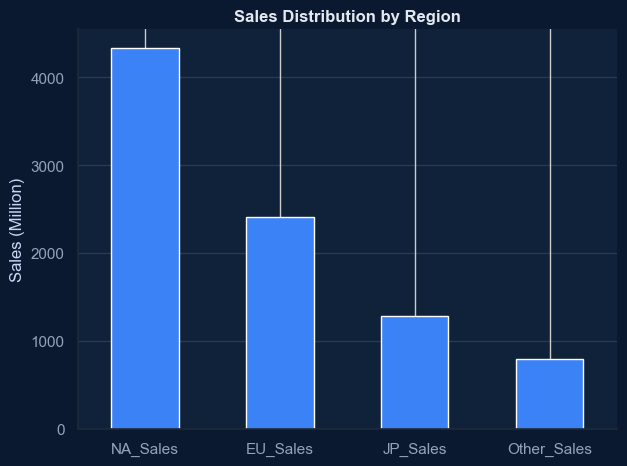

In [37]:
region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure()

ax = region_sales.plot(kind='bar')

plt.title('Sales Distribution by Region')
plt.ylabel('Sales (Million)')

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

📌 Insight
- North America and Europe dominate total sales  
- Japan shows distinct behavior → niche preferences  

##### 📊 5.4 Trend Over Time

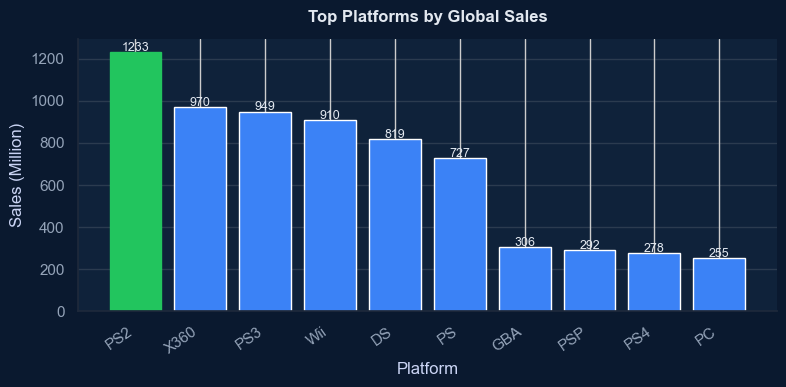

In [38]:
platform_sales = (
    df.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))

bars = plt.bar(
    platform_sales.index,
    platform_sales.values
)

# 🔥 highlight top platform (ini pengecualian, untuk storytelling)
bars[0].set_color("#22c55e")

plt.title("Top Platforms by Global Sales", pad=12)
plt.xlabel("Platform")
plt.ylabel("Sales (Million)")

plt.xticks(rotation=35, ha='right')

plt.grid(axis='y', alpha=0.15)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# value label
for i, v in enumerate(platform_sales.values):
    plt.text(i, v + 5, f"{v:.0f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

📌 Insight (TOP PLATFORM)
- **PS2 emerges as the top-performing platform globally**
- Followed by X360, PS3, and Wii  
- Indicates that console ecosystems dominate over PC in total sales  

💡 Business Insight
- Platform selection is **critical to commercial success**  
- Developers should prioritize platforms with strong user bases and historical performance  

##### 🌍 5.5 Platform per Region

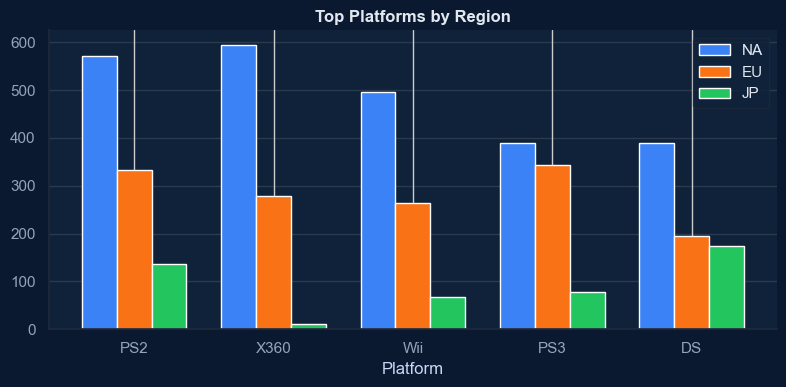

In [18]:
platforms = ['PS2','X360','Wii','PS3','DS']

na = [572, 595, 497, 389, 389]
eu = [332, 278, 264, 343, 194]
jp = [137, 12, 67, 77, 175]

x = np.arange(len(platforms))
width = 0.25

plt.figure(figsize=(8,4))

# 🔥 Modern color palette
colors = {
    "na": "#3b82f6",   # blue
    "eu": "#f97316",   # orange
    "jp": "#22c55e"    # green
}

plt.bar(x - width, na, width, label='NA', color=colors["na"])
plt.bar(x, eu, width, label='EU', color=colors["eu"])
plt.bar(x + width, jp, width, label='JP', color=colors["jp"])

plt.xticks(x, platforms)
plt.title('Top Platforms by Region')
plt.xlabel('Platform')

# grid subtle
plt.grid(axis='y', alpha=0.15)

# remove top/right border
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.legend(facecolor="#0f223a", edgecolor="#1e293b")

plt.tight_layout()
plt.show()

📌 Insight
- NA dominated by X360  
- EU dominated by PlayStation platforms  
- Japan dominated by Nintendo platforms  

👉 Each region has distinct platform preferences  

##### 📅 5.6 Trend Game Release

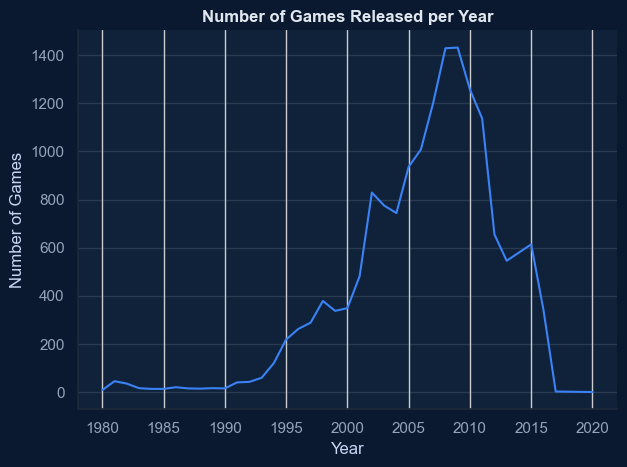

In [39]:
games_per_year = df['Year'].value_counts().sort_index()

plt.figure()

ax = games_per_year.plot()

plt.title('Number of Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')

# subtle grid
plt.grid(axis='y', alpha=0.15)

# clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

📌 Insight
- Peak occurred around **2008–2009**, reflecting industry expansion era  

##### 🔗 5.7 Correlation Between Regions

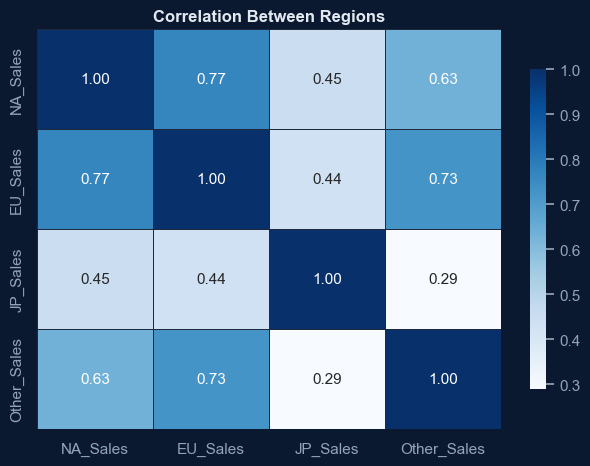

In [40]:
import seaborn as sns

corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()

plt.figure()

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",          # 🔥 sesuai palette kamu
    linewidths=0.5,
    linecolor="#1e293b",   # sesuai edgecolor global
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Between Regions')

# biar konsisten sama dark theme
ax.set_facecolor("#0f223a")

plt.tight_layout()
plt.show()

📌 Insight
- Strong correlation between NA & EU → similar market behavior  
- Japan is less correlated → unique market dynamics  

#### 🧪 6. Statistical Analysis

🎯 T-Test (PC vs X360)

In [19]:
pc = df[df['Platform'] == 'PC']['Global_Sales']
x360 = df[df['Platform'] == 'X360']['Global_Sales']

t_stat, p_value = stats.ttest_ind(pc, x360)

print("P-value:", p_value)

P-value: 3.409027620394838e-19


📌 Insight
- p-value < 0.05 → **Significant difference between platforms**
- Platform choice significantly affects sales performance  

#### 🔍 7. Key Insights

- Nintendo dominates global publisher market  
- Action is the most profitable genre  
- Platform choice significantly impacts sales  
- Strong regional differences exist in gaming preferences  
- PS2 is the highest-selling platform globally  

#### 🚀 8. Business Recommendations

- Focus on Action-based or hybrid genres  
- Tailor game releases based on regional preferences  
- Prioritize high-performing platforms (PS2, X360, PS3)  
- Use data-driven strategy for platform selection  